In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, mutual_info_regression

In [2]:
df = pd.read_csv("santander-customer-transaction-prediction/train.csv")
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [4]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [5]:
df.dtypes.value_counts()

float64    200
object       1
int64        1
Name: count, dtype: int64

In [6]:
df.columns.to_list()

['ID_code',
 'target',
 'var_0',
 'var_1',
 'var_2',
 'var_3',
 'var_4',
 'var_5',
 'var_6',
 'var_7',
 'var_8',
 'var_9',
 'var_10',
 'var_11',
 'var_12',
 'var_13',
 'var_14',
 'var_15',
 'var_16',
 'var_17',
 'var_18',
 'var_19',
 'var_20',
 'var_21',
 'var_22',
 'var_23',
 'var_24',
 'var_25',
 'var_26',
 'var_27',
 'var_28',
 'var_29',
 'var_30',
 'var_31',
 'var_32',
 'var_33',
 'var_34',
 'var_35',
 'var_36',
 'var_37',
 'var_38',
 'var_39',
 'var_40',
 'var_41',
 'var_42',
 'var_43',
 'var_44',
 'var_45',
 'var_46',
 'var_47',
 'var_48',
 'var_49',
 'var_50',
 'var_51',
 'var_52',
 'var_53',
 'var_54',
 'var_55',
 'var_56',
 'var_57',
 'var_58',
 'var_59',
 'var_60',
 'var_61',
 'var_62',
 'var_63',
 'var_64',
 'var_65',
 'var_66',
 'var_67',
 'var_68',
 'var_69',
 'var_70',
 'var_71',
 'var_72',
 'var_73',
 'var_74',
 'var_75',
 'var_76',
 'var_77',
 'var_78',
 'var_79',
 'var_80',
 'var_81',
 'var_82',
 'var_83',
 'var_84',
 'var_85',
 'var_86',
 'var_87',
 'var_88',
 'var_89

In [7]:
df.columns.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum().sum()


np.int64(0)

In [9]:
target_col = "target"
y = df[target_col]
X = df.drop(columns=[target_col, "ID_code"])



In [10]:
y.describe()

count    200000.000000
mean          0.100490
std           0.300653
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: target, dtype: float64

{'whiskers': [<matplotlib.lines.Line2D at 0x1cdcea38190>,
 'caps': [<matplotlib.lines.Line2D at 0x1cdcea3aad0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1cdce3d2710>],
 'medians': [<matplotlib.lines.Line2D at 0x1cdcea3ad50>],
 'fliers': [<matplotlib.lines.Line2D at 0x1cdcea3ae90>],
 'means': []}

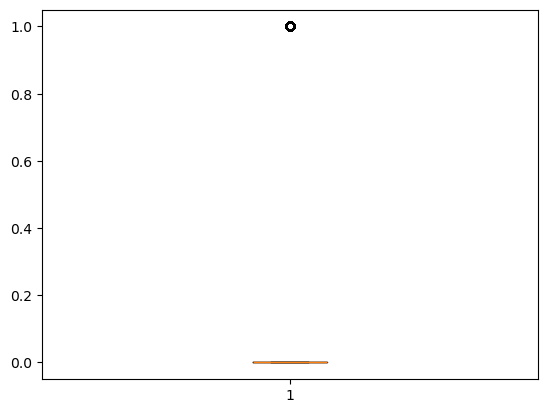

In [11]:
plt.boxplot(y)

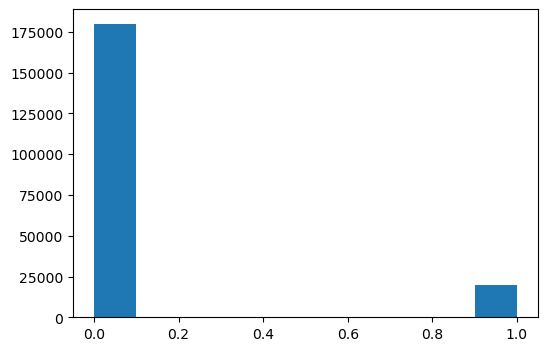

In [12]:
plt.figure(figsize=(6,4))
plt.hist(y)
plt.show()

In [13]:
X.mean()

var_0      10.679914
var_1      -1.627622
var_2      10.715192
var_3       6.796529
var_4      11.078333
             ...    
var_195    -0.142088
var_196     2.303335
var_197     8.908158
var_198    15.870720
var_199    -3.326537
Length: 200, dtype: float64

In [14]:
iqr_results = []

for col in X.columns:

    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = (
        (X[col] < lower) |
        (X[col] > upper)
    ).sum()

    iqr_results.append({
        "feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": outlier_count,
        "outlier_percent": (
            outlier_count / len(X) * 100
        )
    })

iqr_df = pd.DataFrame(iqr_results)

iqr_df = iqr_df.sort_values(
    "outlier_count",
    ascending=False
)

print(iqr_df.head(20))

     feature         Q1         Q3        IQR  lower_bound  upper_bound  \
179  var_179   0.625575   4.391125   3.765550    -5.022750    10.039450   
44    var_44   5.313650  13.087300   7.773650    -6.346825    24.747775   
93    var_93  10.195600  10.944900   0.749300     9.071650    12.068850   
146  var_146   8.646900  12.113225   3.466325     3.447413    17.312712   
192  var_192   0.889775   2.949500   2.059725    -2.199813     6.039088   
31    var_31   8.870000  11.885000   3.015000     4.347500    16.407500   
133  var_133   6.543500   7.070800   0.527300     5.752550     7.861750   
105  var_105   3.639600   4.822200   1.182600     1.865700     6.596100   
38    var_38   7.591050  13.598925   6.007875    -1.420763    22.610738   
124  var_124   2.353600   6.192200   3.838600    -3.404300    11.950100   
110  var_110   2.817475   8.104325   5.286850    -5.112800    16.034600   
67    var_67   6.753200  17.037650  10.284450    -8.673475    32.464325   
193  var_193   0.584600  

In [15]:

zscore_results = []

for col in X.columns :
    mean = X[col].mean()
    std = X[col].std()

    if std == 0:
        outlier_count = 0
    else:
        z_scores = (X[col] - mean) / std
        outlier_count = (np.abs(z_scores) > 3).sum()

    zscore_results.append({
        "feature": col,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_count / len(X) * 100
    })

zscore_df = pd.DataFrame(zscore_results)

zscore_df = zscore_df.sort_values(
    "outlier_count",
    ascending=False
)

zscore_df.head(20)

,feature,outlier_count,outlier_percent
179,var_179,429,0.2145
192,var_192,306,0.1530
93,var_93,271,0.1355
146,var_146,268,0.1340
31,var_31,254,0.1270
38,var_38,245,0.1225
133,var_133,228,0.1140
124,var_124,214,0.1070
170,var_170,196,0.0980
186,var_186,191,0.0955


In [16]:
comparison = zscore_df[
    ["feature", "outlier_count", "outlier_percent"]
].merge(
    iqr_df[
        ["feature", "outlier_count", "outlier_percent"]
    ],
    on="feature",
    suffixes=("_zscore", "_iqr")
)

comparison = comparison.sort_values(
    "outlier_count_iqr",
    ascending=False
)

comparison.head(20)

,feature,outlier_count_zscore,outlier_percent_zscore,outlier_count_iqr,outlier_percent_iqr
0,var_179,429,0.2145,1509,0.7545
73,var_44,50,0.0250,1208,0.6040
2,var_93,271,0.1355,889,0.4445
3,var_146,268,0.1340,804,0.4020
1,var_192,306,0.1530,733,0.3665
4,var_31,254,0.1270,637,0.3185
6,var_133,228,0.1140,589,0.2945
16,var_105,172,0.0860,572,0.2860
5,var_38,245,0.1225,502,0.2510
7,var_124,214,0.1070,498,0.2490


In [17]:
for threshold in [0.1, 1, 5, 10]:

    z_count = (
        zscore_df["outlier_percent"] >= threshold
    ).sum()

    iqr_count = (
        iqr_df["outlier_percent"] >= threshold
    ).sum()

    print(
        f"{threshold}% → "
        f"Z-Score: {z_count} features | "
        f"IQR: {iqr_count} features"
    )

0.1% → Z-Score: 8 features | IQR: 42 features
1% → Z-Score: 0 features | IQR: 0 features
5% → Z-Score: 0 features | IQR: 0 features
10% → Z-Score: 0 features | IQR: 0 features


In [18]:
print("Z-Score features:")
print(
    zscore_df[
        zscore_df["outlier_percent"] >= 0.1
    ][["feature", "outlier_count", "outlier_percent"]]
)

print("\nIQR features:")
print(
    iqr_df[
        iqr_df["outlier_percent"] >= 0.1
    ][["feature", "outlier_count", "outlier_percent"]]
)

Z-Score features:
     feature  outlier_count  outlier_percent
179  var_179            429           0.2145
192  var_192            306           0.1530
93    var_93            271           0.1355
146  var_146            268           0.1340
31    var_31            254           0.1270
38    var_38            245           0.1225
133  var_133            228           0.1140
124  var_124            214           0.1070

IQR features:
     feature  outlier_count  outlier_percent
179  var_179           1509           0.7545
44    var_44           1208           0.6040
93    var_93            889           0.4445
146  var_146            804           0.4020
192  var_192            733           0.3665
31    var_31            637           0.3185
133  var_133            589           0.2945
105  var_105            572           0.2860
38    var_38            502           0.2510
124  var_124            498           0.2490
110  var_110            470           0.2350
67    var_67          

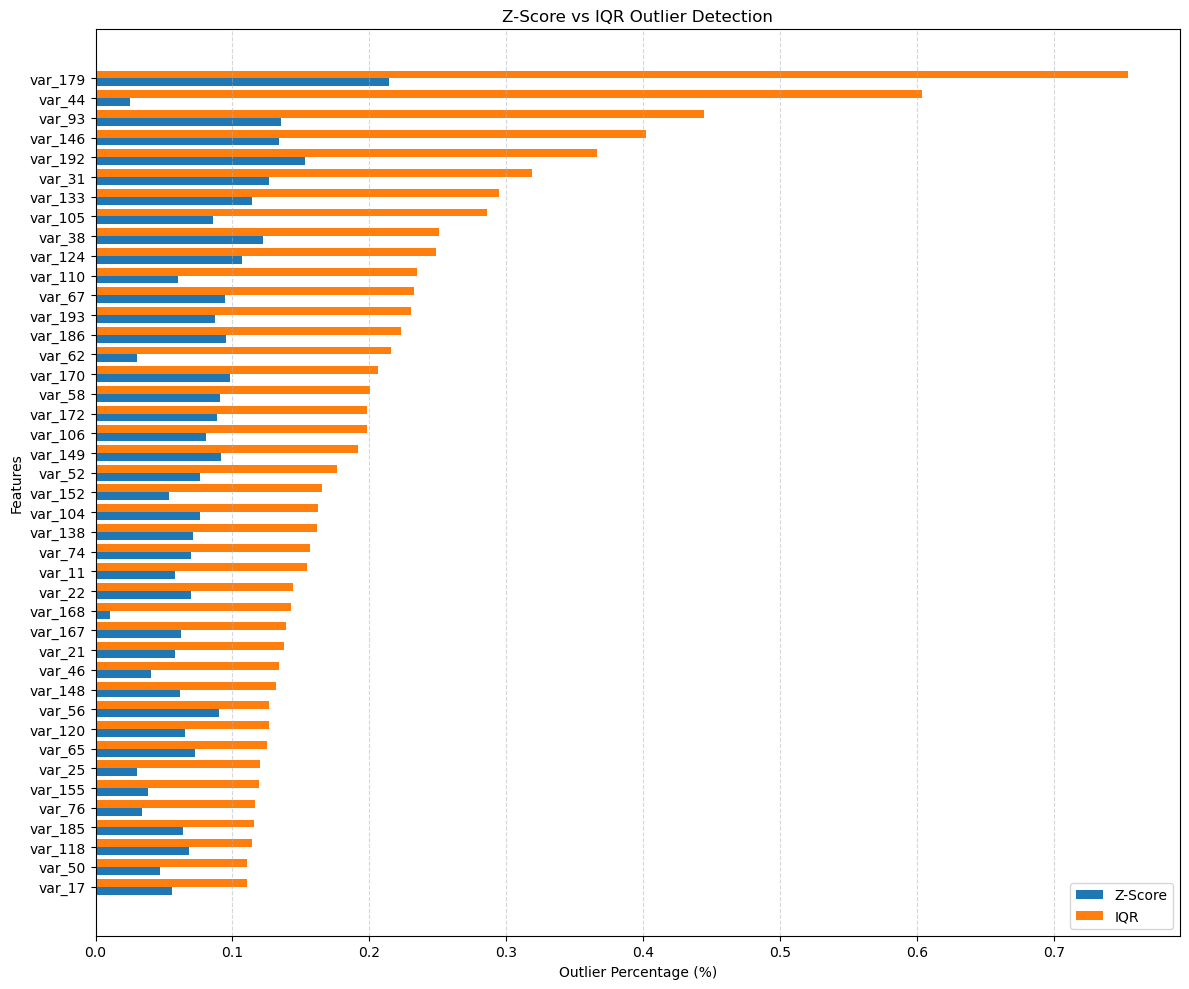

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

# ادغام دو دیتافریم
compare_df = pd.merge(
    zscore_df[["feature", "outlier_percent"]],
    iqr_df[["feature", "outlier_percent"]],
    on="feature",
    suffixes=("_zscore", "_iqr")
)

# فقط فیچرهای مهم
compare_df = compare_df[
    (compare_df["outlier_percent_zscore"] >= 0.1) |
    (compare_df["outlier_percent_iqr"] >= 0.1)
]

compare_df = compare_df.sort_values(
    "outlier_percent_iqr",
    ascending=True
)

plt.figure(figsize=(12, 10))

y = range(len(compare_df))

plt.barh(
    [i - 0.2 for i in y],
    compare_df["outlier_percent_zscore"],
    height=0.4,
    label="Z-Score"
)

plt.barh(
    [i + 0.2 for i in y],
    compare_df["outlier_percent_iqr"],
    height=0.4,
    label="IQR"
)

plt.yticks(y, compare_df["feature"])

plt.xlabel("Outlier Percentage (%)")
plt.ylabel("Features")
plt.title("Z-Score vs IQR Outlier Detection")

plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

<div dir="rtl">
چون بیشترین Outlier در کل ۲۰۰ ستون هم فقط حدود ۰.۷٪ بوده، فعلاً کل مرحله‌ی Outlier Treatment را می‌توانیم Skip کنیم.
<div>

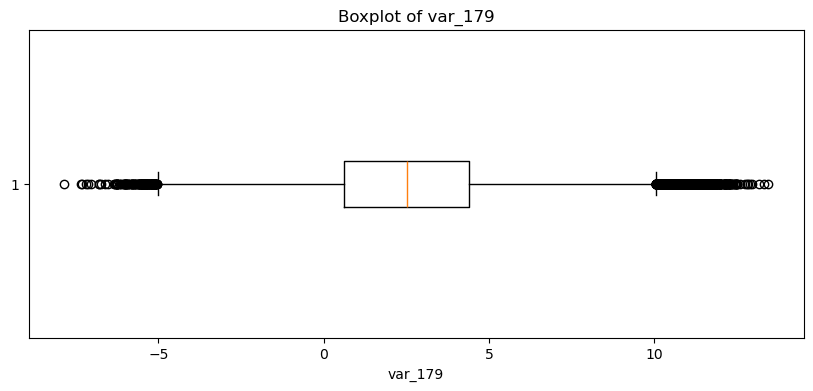

In [20]:


plt.figure(figsize=(10, 4))
plt.boxplot(df["var_179"].dropna(), vert=False)
plt.title("Boxplot of var_179")
plt.xlabel("var_179")
plt.show()

In [25]:
col = "var_179"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower) | (df[col] > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Outlier count:", len(outliers))
print("Outlier percent:", len(outliers) / len(df) * 100)

Q1: 0.625575
Q3: 4.391125
IQR: 3.7655499999999997
Lower bound: -5.02275
Upper bound: 10.039449999999999
Outlier count: 1509
Outlier percent: 0.7545


In [26]:
outliers[["var_179"]].head(20)

,var_179
1,11.0752
105,10.1314
136,-5.7020
230,11.1955
436,11.6486
558,10.4202
592,-5.3148
660,11.2206
887,11.1902
1083,11.0247


In [27]:
outliers = df[
    (df["var_179"] < lower) |
    (df["var_179"] > upper)
]

print(outliers["target"].value_counts())
print(outliers["target"].value_counts(normalize=True) * 100)

target
0    1242
1     267
Name: count, dtype: int64
target
0    82.306163
1    17.693837
Name: proportion, dtype: float64
